In [44]:
import pandas as pd
import yfinance as yf
from pypfopt import EfficientFrontier, risk_models, expected_returns, plotting
import matplotlib.pyplot as plt

tickers = [
    "VWRA.L",  # Vanguard FTSE All-World UCITS ETF (renta variable global, acumulación)
    "AGGU.L",  # iShares Core Global Aggregate Bond UCITS ETF (renta fija global, hedged USD)
    "ZPRV.DE",  # SPDR MSCI USA Small Cap Value Weighted UCITS ETF (small caps value EE.UU.)
    "FUSD.L",  # Fidelity US Quality Income UCITS ETF (calidad/dividendos EE.UU.)
    "EIMI.L",  # iShares Core MSCI Emerging Markets IMI UCITS ETF (mercados emergentes)
    "SMGB.L",  # VanEck Semiconductor UCITS ETF (sector semiconductores)
]

In [45]:
def get_prices(
    tickers,
):
    df = yf.download(
        tickers, start="2021-01-01", end="2026-01-01", interval="1mo", auto_adjust=True
    )

    prices = df["Close"]
    if isinstance(prices.columns, pd.MultiIndex):
        prices.columns = prices.columns.get_level_values(0)
    prices.columns = prices.columns.str.upper()
    prices.index = prices.index.normalize()
    return prices

In [46]:
prices = get_prices(tickers)
prices.to_csv("precios_mensuales.csv")

[*********************100%***********************]  6 of 6 completed


In [47]:

print(prices.tail(10))
print(f"\nShape: {prices.shape}")
print(f"Rango: {prices.index[0].date()} -> {prices.index[-1].date()}")

Ticker      AGGU.L     EIMI.L     FUSD.L     SMGB.L      VWRA.L    ZPRV.DE
Date                                                                      
2025-03-01   5.593  34.830002  10.093105  27.607500  136.100006  59.060001
2025-04-01   5.650  35.070000   9.960657  26.762501  137.220001  53.720001
2025-05-01   5.638  36.770000  10.544413  30.139999  145.779999  57.060001
2025-06-01   5.683  39.290001  10.988058  34.349998  152.460007  57.799999
2025-07-01   5.690  39.810001  11.335203  36.590000  155.460007  60.750000
2025-08-01   5.713  40.720001  11.505084  35.992500  158.500000  63.389999
2025-09-01   5.759  43.189999  11.798261  40.525002  163.679993  63.630001
2025-10-01   5.796  44.750000  12.010886  47.014999  167.880005  64.739998
2025-11-01   5.809  44.189999  12.174065  45.325001  167.919998  66.959999
2025-12-01   5.810  45.119999  12.295094  46.230000  170.619995  67.139999

Shape: (60, 6)
Rango: 2021-01-01 -> 2025-12-01


In [48]:
mu = expected_returns.mean_historical_return(prices, frequency = 12)
print(mu)

Ticker
AGGU.L     0.001972
EIMI.L     0.041982
FUSD.L     0.133059
SMGB.L     0.241920
VWRA.L     0.115152
ZPRV.DE    0.125124
dtype: float64


In [49]:
# Calculemos la matriz de covarianza con datos mensuales
S = risk_models.sample_cov(prices, frequency = 12)
print(S)

Ticker     AGGU.L    EIMI.L    FUSD.L    SMGB.L    VWRA.L   ZPRV.DE
Ticker                                                             
AGGU.L   0.002425  0.004416  0.004252  0.006261  0.004715  0.003157
EIMI.L   0.004416  0.022223  0.011880  0.019415  0.014919  0.008645
FUSD.L   0.004252  0.011880  0.016445  0.019165  0.015876  0.017809
SMGB.L   0.006261  0.019415  0.019165  0.071306  0.022195  0.020819
VWRA.L   0.004715  0.014919  0.015876  0.022195  0.017081  0.016367
ZPRV.DE  0.003157  0.008645  0.017809  0.020819  0.016367  0.038611


In [85]:
irx = yf.Ticker("^IRX")
data = irx.history(period="30y", interval="1mo")
print(data["Close"].iloc[-1])
tasa_libre_de_riesgo = data["Close"].iloc[-1] / 100


3.6349997520446777


In [95]:
ef = EfficientFrontier(mu, S, weight_bounds=(0.05, 0.55))

# VWRA
ef.add_constraint(lambda w: w[4] >= 0.45)
ef.add_constraint(lambda w: w[4] <= 0.55)


# AGGU
ef.add_constraint(lambda w: w[0] >= 0.10)

# ZPRV
ef.add_constraint(lambda w: w[5] >= 0.05)
ef.add_constraint(lambda w: w[5] <= 0.20)

# FUSD
ef.add_constraint(lambda w: w[2] >= 0.05)
ef.add_constraint(lambda w: w[2] <= 0.20)

# EIMI
ef.add_constraint(lambda w: w[1] >= 0.05)
ef.add_constraint(lambda w: w[1] <= 0.15)

# SMGB
ef.add_constraint(lambda w: w[3] >= 0.10)

pesos_optimizados = ef.max_sharpe(risk_free_rate=tasa_libre_de_riesgo)
pesos_optimizados = ef.clean_weights()
print(pesos_optimizados)
rendimiento, volatilidad, ratio_sharpe = ef.portfolio_performance(verbose=True, risk_free_rate=tasa_libre_de_riesgo)

OrderedDict({'AGGU.L': 0.1, 'EIMI.L': 0.05, 'FUSD.L': 0.05, 'SMGB.L': 0.3, 'VWRA.L': 0.45, 'ZPRV.DE': 0.05})
Expected annual return: 14.0%
Annual volatility: 14.5%
Sharpe Ratio: 0.71


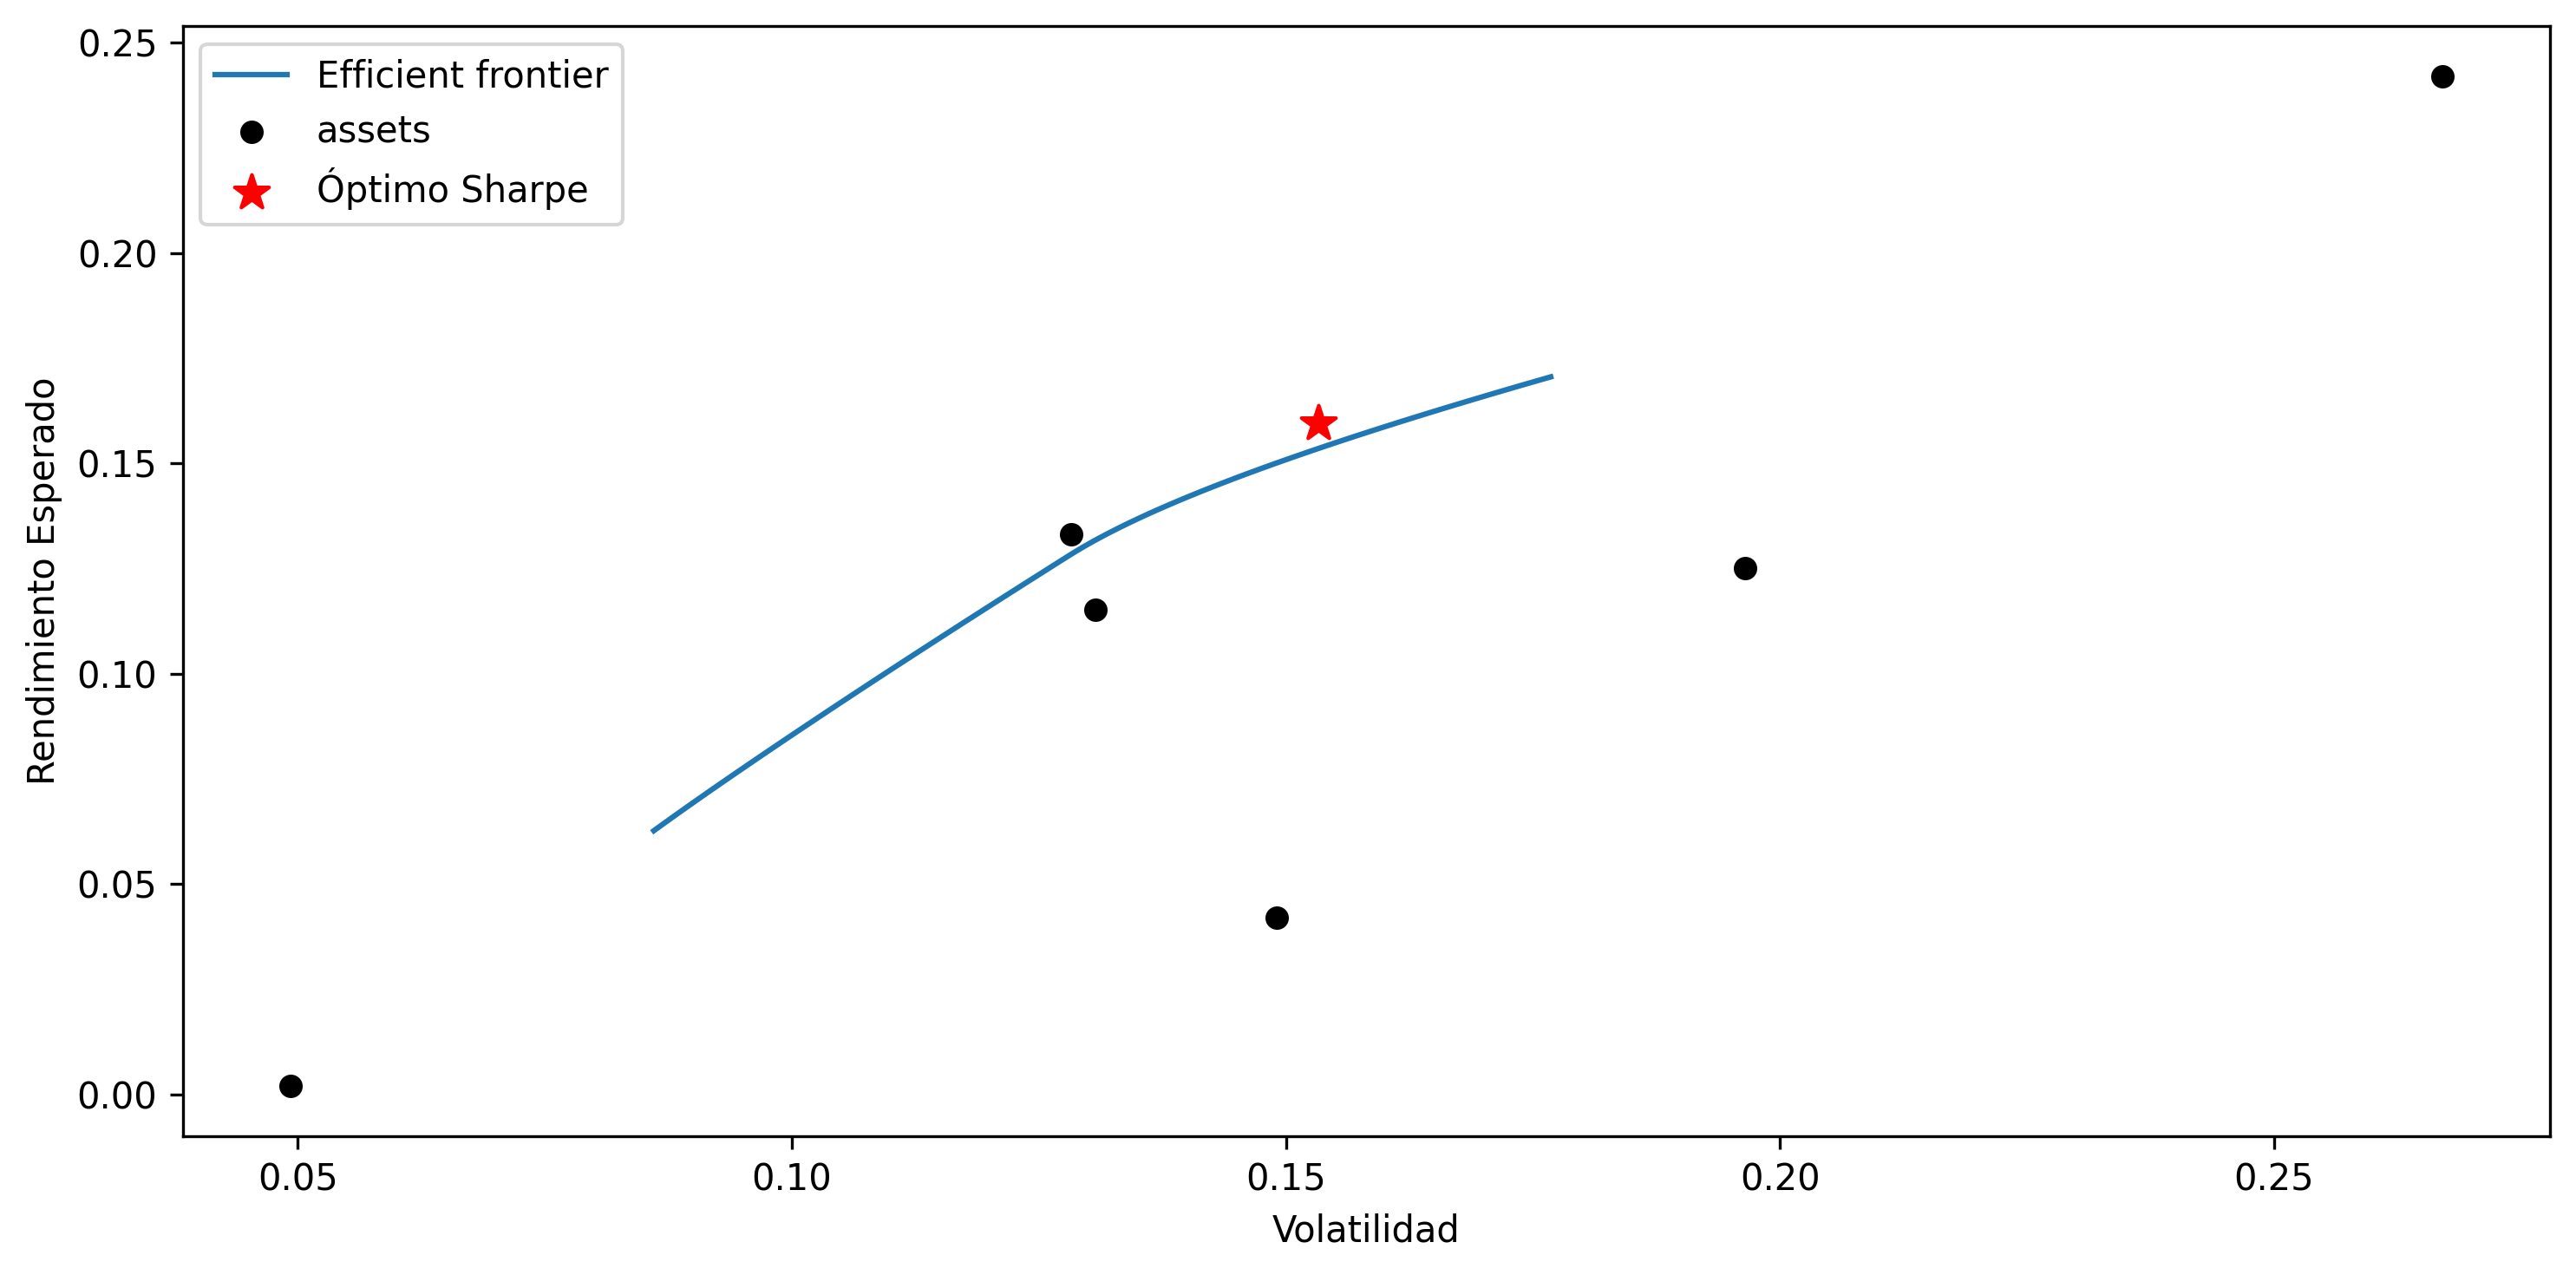

In [ ]:
ef = EfficientFrontier(mu, S, weight_bounds=(0.05, 0.55))

fig, ax = plt.subplots(figsize=(10, 5), dpi=300)
plotting.plot_efficient_frontier(ef, ax=ax, show_assets=True)
ax.scatter(volatilidad, rendimiento, marker="*", color="r", s=100, label="Óptimo Sharpe")
ax.legend()
ax.set_xlabel("Volatilidad")
ax.set_ylabel("Rendimiento Esperado")
plt.show()